In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('student_habits_performance.csv')

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

# EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [6]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [7]:
df.describe(include="object")

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,909,1000,1000
unique,1000,3,2,3,3,3,2
top,S1999,Female,No,Fair,High School,Good,No
freq,1,481,785,437,392,447,682


In [8]:
# df.describe(include="object").columns

In [9]:
catagorical_col = ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [10]:
df['age'].value_counts()

age
20    146
24    134
17    133
21    125
23    119
18    117
19    113
22    113
Name: count, dtype: int64

In [11]:
for col in catagorical_col:
    
    print(f"Value count for {col} \n {df[col].value_counts()}")

Value count for gender 
 gender
Female    481
Male      477
Other      42
Name: count, dtype: int64
Value count for part_time_job 
 part_time_job
No     785
Yes    215
Name: count, dtype: int64
Value count for diet_quality 
 diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64
Value count for parental_education_level 
 parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value count for internet_quality 
 internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64
Value count for extracurricular_participation 
 extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64


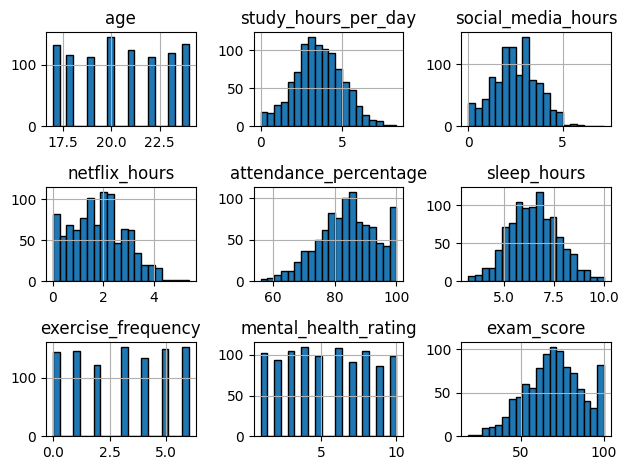

In [12]:
df.hist(bins=20, edgecolor = 'black')
plt.tight_layout()
plt.show()

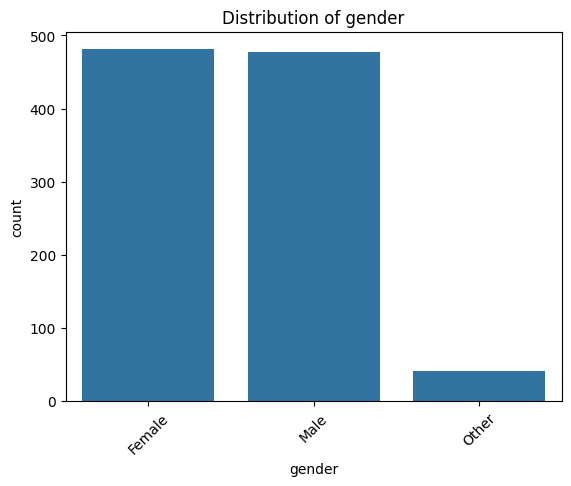

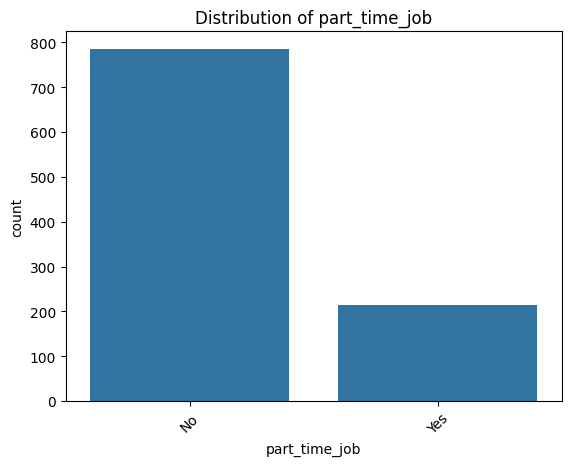

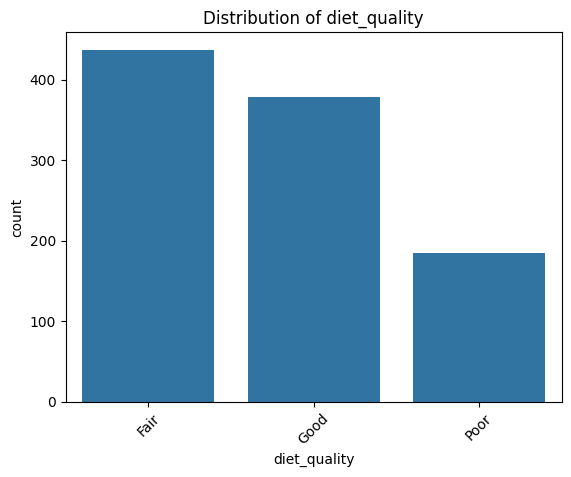

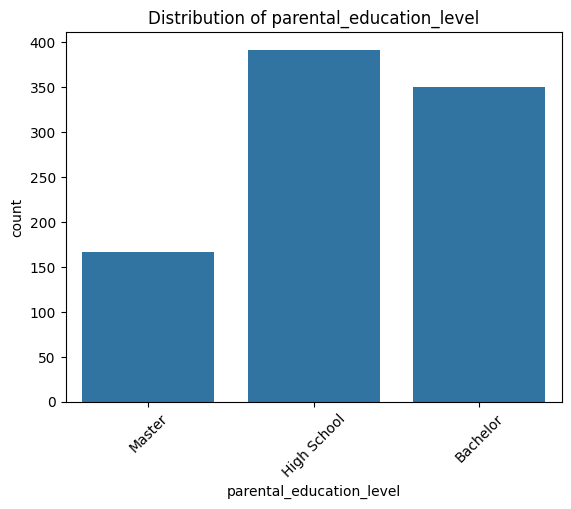

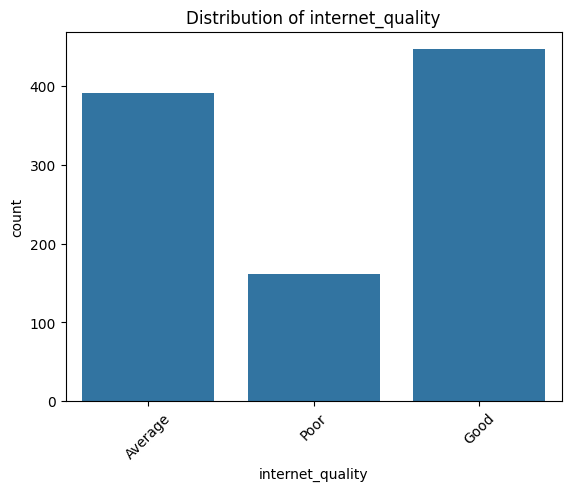

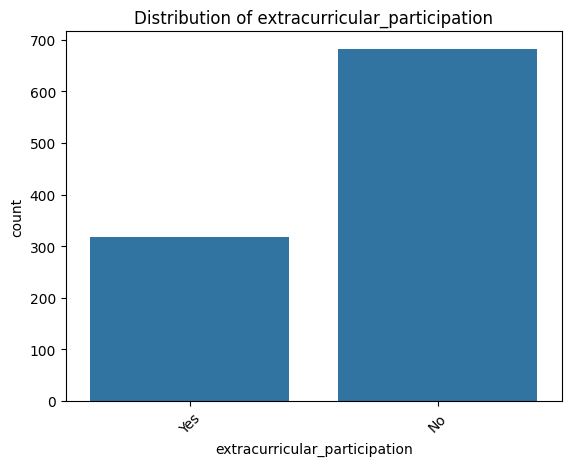

In [13]:
for col in catagorical_col:
    sns.countplot(x = df[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation =45)
    plt.show()

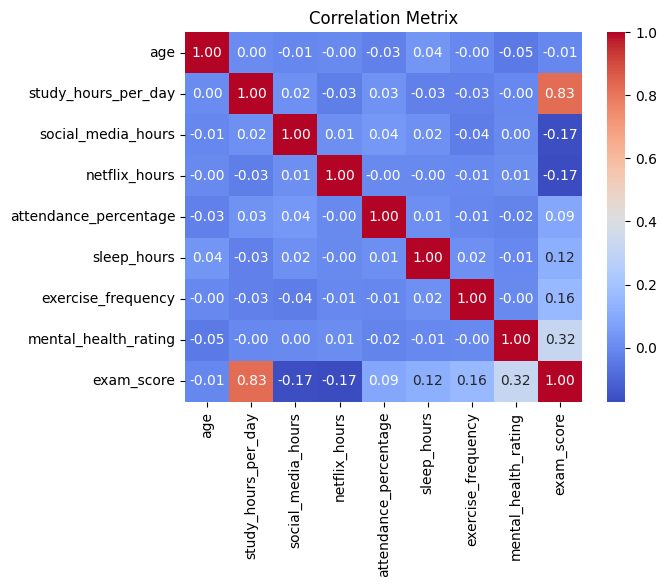

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Correlation Metrix")
plt.show()

In [15]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [16]:
num_cols = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

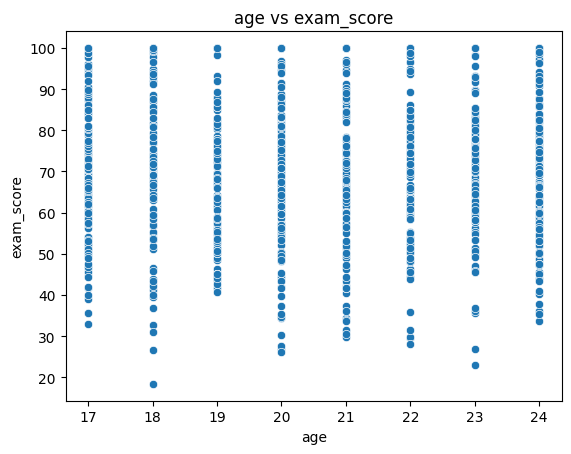

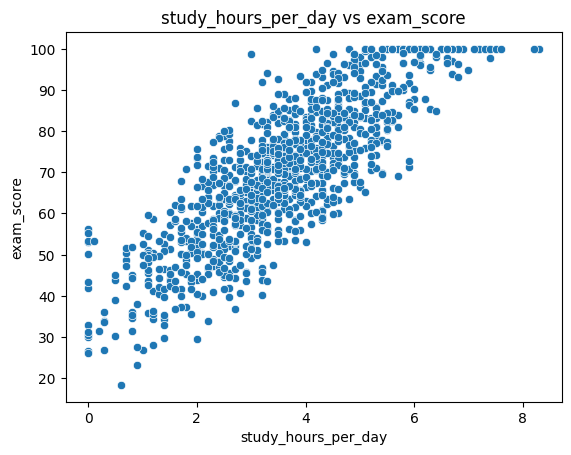

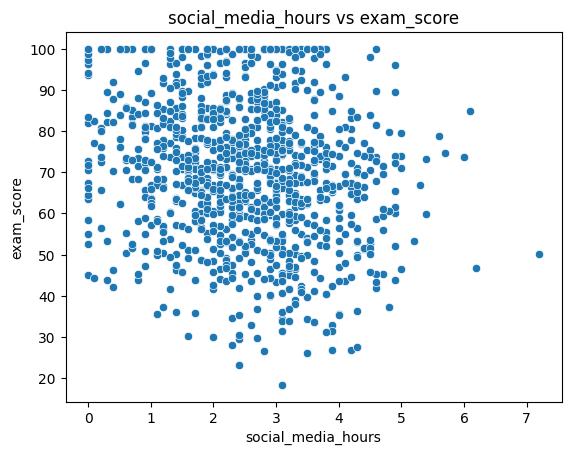

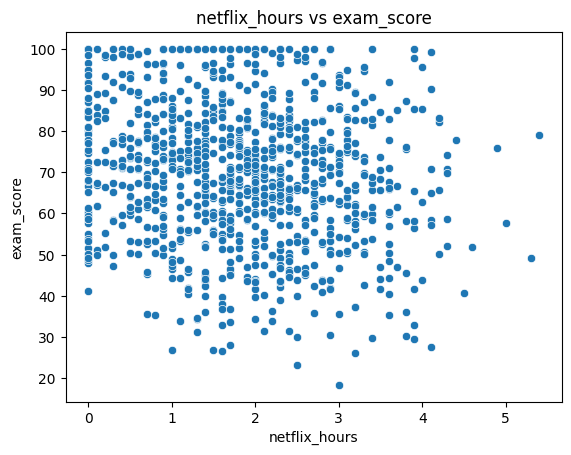

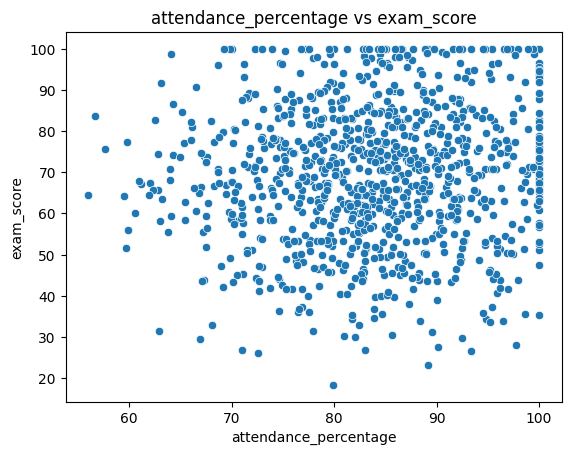

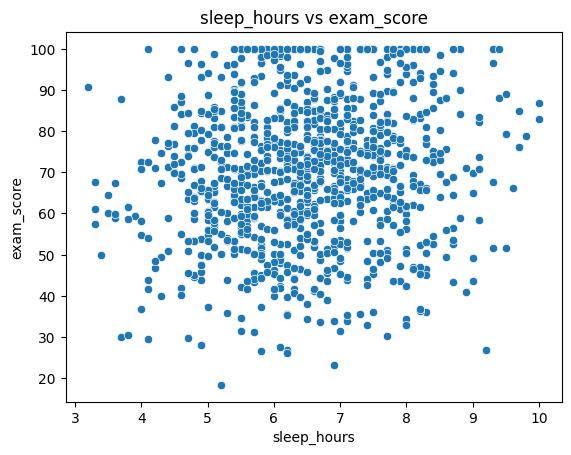

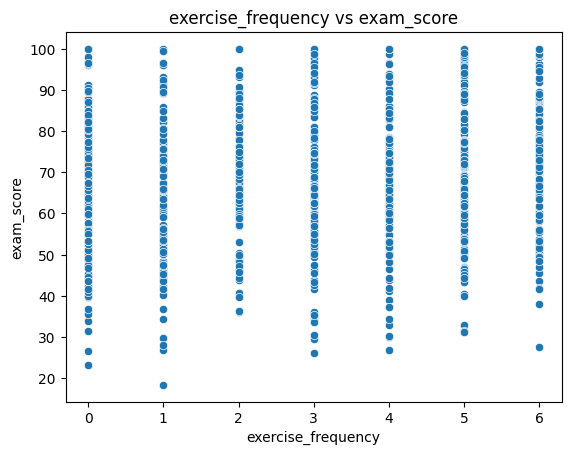

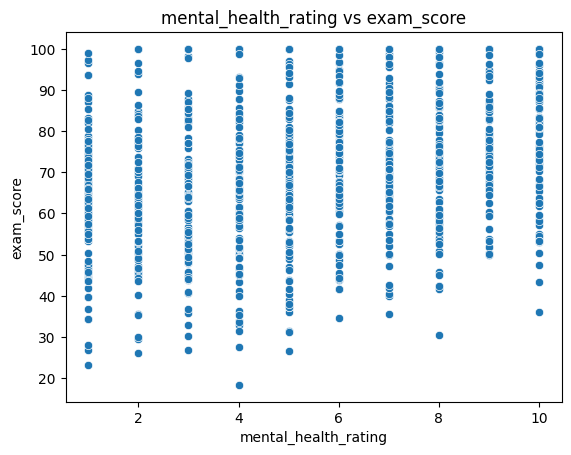

In [17]:
for col in num_cols:
    sns.scatterplot(x = df[col], y = df['exam_score'])
    plt.title(f"{col} vs exam_score")
    plt.show()

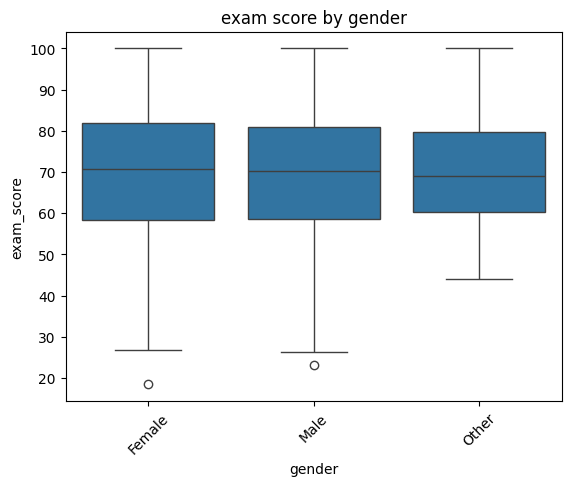

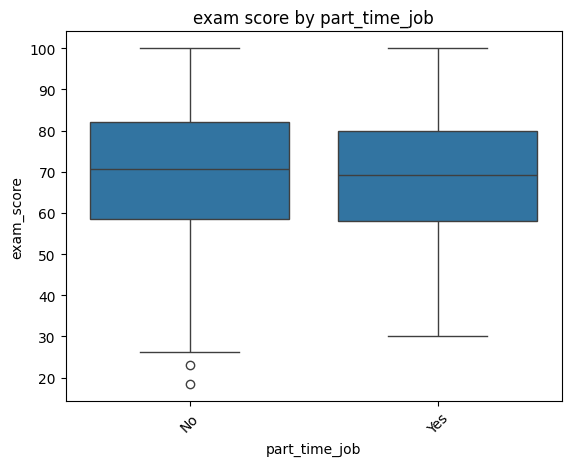

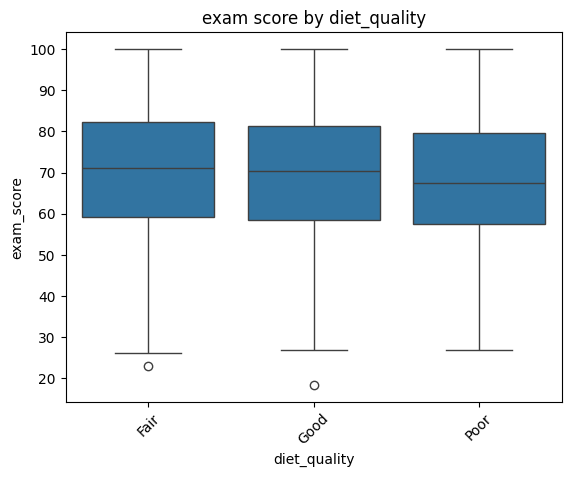

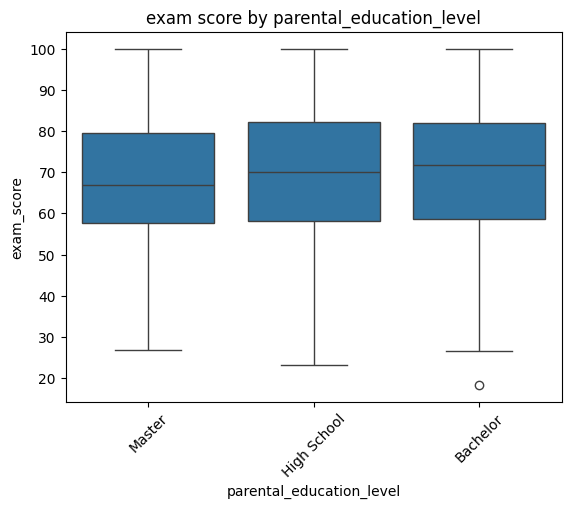

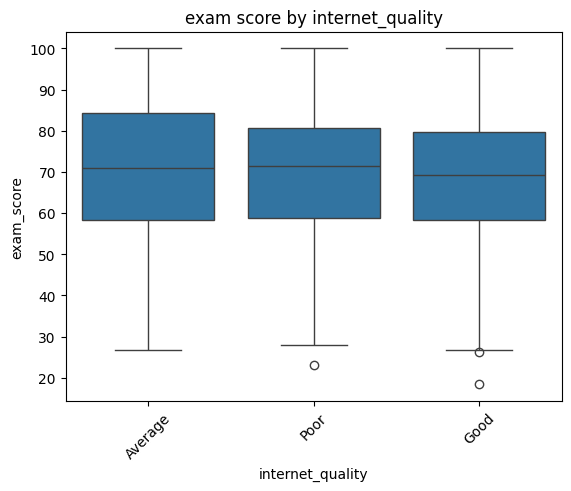

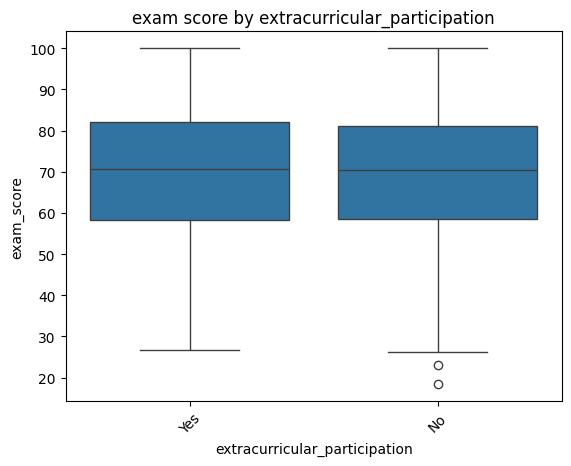

In [18]:
for col in catagorical_col:
    sns.boxplot(x = df[col], y = df['exam_score'])
    plt.title(f"exam score by {col}")
    plt.xticks(rotation = 45)
    plt.show()

# Feature Engineering and Creating Models

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score, mean_absolute_error

from xgboost import XGBRegressor

In [20]:
df.drop(columns=['student_id'], inplace=True)

In [21]:
X = df.drop(columns=['exam_score'])
y = df['exam_score']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
num_cols = [
    'age', 'study_hours_per_day', 'social_media_hours',
    'netflix_hours', 'sleep_hours',
    'exercise_frequency', 'mental_health_rating'
]

In [24]:
binary_cols = ['gender', 'part_time_job', 'extracurricular_participation']

In [25]:
ordinal_cols = [
    'diet_quality',
    'parental_education_level',
    'internet_quality'
]

In [26]:
diet_order = ['Poor', 'Fair', 'Good']

education_order = ['High School', 'Bachelor', 'Master']

internet_order = ['Poor', 'Average', 'Good']

In [27]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary'))
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        diet_order,
        education_order,
        internet_order
    ]))
])

In [28]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('bin', binary_pipeline, binary_cols),
    ('ord', ordinal_pipeline, ordinal_cols)
])


In [29]:
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            'model__max_depth': [3, 5, 10],
            'model__min_samples_split': [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 5, 10]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5]
        }
    }
}

In [30]:
results = []

best_model = None
best_score = -np.inf

for name, config in models.items():
    print(f"\nTraining {name}...")
    
    pipe = Pipeline([
        ('preprocessing', preprocessor),
        ('model', config['model'])
    ])
    
    grid = GridSearchCV(
        pipe,
        config['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    y_pred = grid.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE": round(mae, 4),
        "Best Parameters": grid.best_params_
    })
    
    if r2 > best_score:
        best_score = r2
        best_model = grid.best_estimator_

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)



Training Linear Regression...

Training Decision Tree...

Training Random Forest...

Training XGBoost...


In [31]:
results_df.style.background_gradient(cmap='Blues').set_caption("Model Performance Comparison")

,Model,R2 Score,MAE,Best Parameters
0,Linear Regression,0.892700,4.287200,{}
1,XGBoost,0.874900,4.707400,"{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}"
2,Random Forest,0.848100,5.024400,"{'model__max_depth': None, 'model__n_estimators': 200}"
3,Decision Tree,0.705100,6.896400,"{'model__max_depth': 5, 'model__min_samples_split': 10}"


In [32]:
print("\nBest Model Summary:")
print("Model Name:", results_df.iloc[0]['Model'])
print("Best R2 Score:", results_df.iloc[0]['R2 Score'])
print("Best Parameters:", results_df.iloc[0]['Best Parameters'])


Best Model Summary:
Model Name: Linear Regression
Best R2 Score: 0.8927
Best Parameters: {}
